In [1]:
# Install YOLO + Roboflow
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
# Import required libraries

from roboflow import Roboflow
from ultralytics import YOLO

import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="DrMInrTDpSwQYduMzhxK")
project = rf.workspace("saeers-workspace").project("pakistani-currency-detection-opsrw")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pakistani-currency-detection-1 in yolov8:: 100%|██████████| 7227/7227 [00:00<00:00, 7283.77it/s]


In [4]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model (small version for balance)
model = YOLO("yolov8s.pt")

In [5]:
# =========================
# CHECK DATASET LOCATION
# =========================

import os

print("Dataset path:", dataset.location)
# print(dataset.location)
# os.listdir(dataset.location)

# List files to confirm structure
os.listdir(dataset.location)

Dataset path: /content/pakistani-currency-detection-1


['train',
 'data.yaml',
 'valid',
 'test',
 'README.roboflow.txt',
 'README.dataset.txt']

In [6]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=-1,
    cache="disk",
    workers=4,
    patience=5,
    name="currency_detection_model_v2",

    degrees=15.0,     # Rotates images slightly (helps with angled notes)
    hsv_h=0.015,      # Randomly shifts color hue (helps with lighting variations)
    hsv_v=0.4,        # Randomly shifts brightness (fixes low-light false negatives)
    scale=0.5,        # Zooms in/out randomly (fixes notes missed far away)
    mosaic=1.0,       # Stitches 4 images into 1 (excellent for small/crowded notes)
    mixup=0.2         # Blends two images together (forces the model to look harder)
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pakistani-currency-detection-1/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=currency_detection_model_v2, nbs=64, nms=False, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e00c1eeba40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [7]:
# Check training output folder
!ls runs/detect/

currency_detection_model_v2


In [8]:
import glob


# 1. Path to your test images folder (Roboflow usually sets it up under dataset.location/test/images)
test_images_path = f"{dataset.location}/test/images/*.jpg"
image_files = glob.glob(test_images_path)

print(f"📸 Found {len(image_files)} images for prediction.")

results = model.predict(
    source=image_files[:10], # Predicts on the first 10 images (change or remove [:10] for all)
    conf=0.20,     #
    iou=0.45,       # Non-Maximum Suppression threshold
    save=True
)

print(f"🚀 Predictions finished! Cropped/Annotated images saved to: {results[0].save_dir}")

📸 Found 361 images for prediction.

0: 640x640 1 50 Rupees, 10.3ms
1: 640x640 1 100 Rupees, 10.3ms
2: 640x640 1 100 Rupees, 10.3ms
3: 640x640 1 5000 Rupees, 10.3ms
4: 640x640 1 20 Rupees, 10.3ms
5: 640x640 1 1000 Rupees, 10.3ms
6: 640x640 1 50 Rupees, 10.3ms
7: 640x640 1 500 Rupees, 10.3ms
8: 640x640 1 500 Rupees, 10.3ms
9: 640x640 1 20 Rupees, 10.3ms
Speed: 3.5ms preprocess, 10.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
🚀 Predictions finished! Cropped/Annotated images saved to: /content/runs/detect/predict


In [9]:
# Model evaluation metrics
model.val()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 79.9±123.4 MB/s, size: 51.2 KB)
val: Scanning /content/pakistani-currency-detection-1/valid/labels.cache... 722 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 722/722 178.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 3.3it/s 14.1s
                   all        722        734      0.997      0.983       0.99      0.807
             10 Rupees        128        128      0.991      0.992      0.995      0.806
            100 Rupees        105        105          1      0.997      0.995      0.821
           1000 Rupees         84         85      0.998      0.941      0.974      0.797
             20 Rupees        113        113      0.998          1      0.995      0.821
             50 Rupees        100        101          1      0.981      0.995      0.798
            500 R

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e0127bcad80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [10]:
# ==========================================
# DOWNLOAD BEST TRAINED YOLO MODEL
# ==========================================

from google.colab import files

# Path where YOLO saves best model
model_path = "runs/detect/currency_detection_model_v2/weights/best.pt"

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Contents of training run directory (/content/runs/detect/currency_detection_model_v2):
  - train_batch6321.jpg
  - args.yaml
  - val_batch0_labels.jpg
  - results.png
  - weights
  - BoxP_curve.png
  - train_batch6322.jpg
  - BoxR_curve.png
  - val_batch2_pred.jpg
  - BoxPR_curve.png
  - confusion_matrix.png
  - results.csv
  - val_batch2_labels.jpg
  - labels.jpg
  - train_batch6320.jpg
  - val_batch1_labels.jpg
  - train_batch1.jpg
  - confusion_matrix_normalized.png
  - train_batch0.jpg
  - BoxF1_curve.png
  - val_batch1_pred.jpg
  - train_batch2.jpg
  - val_batch0_pred.jpg


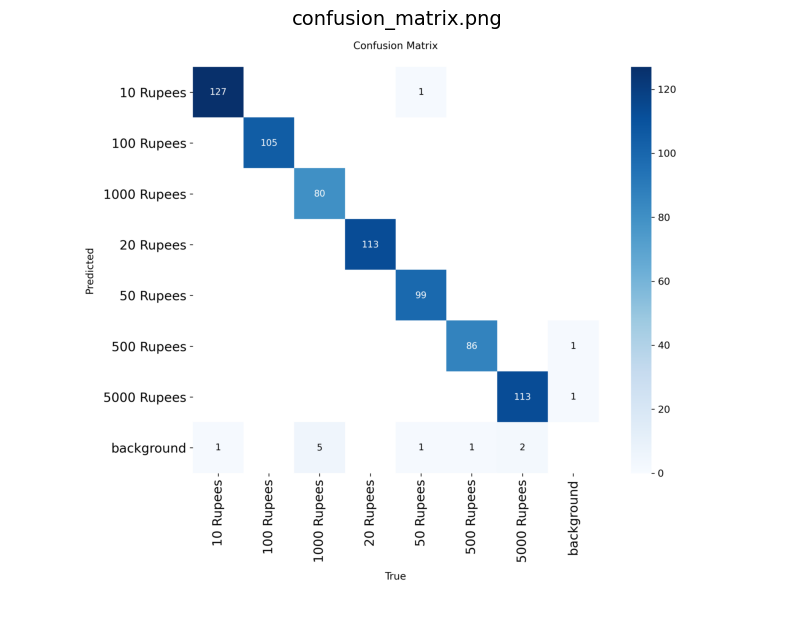

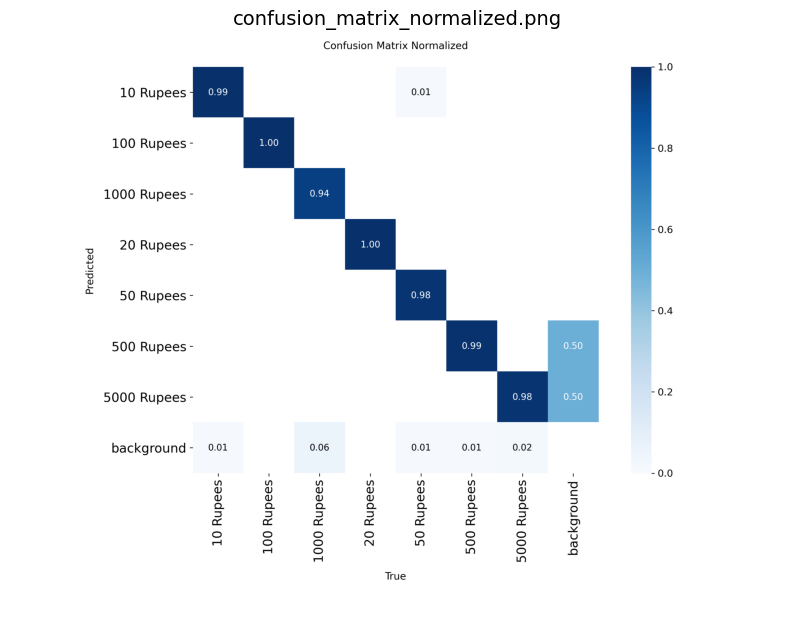

⚠️ Could not find F1_curve.png in /content/runs/detect/val-3 or /content/runs/detect/currency_detection_model_v2
⚠️ Could not find PR_curve.png in /content/runs/detect/val-3 or /content/runs/detect/currency_detection_model_v2


In [15]:
import matplotlib.pyplot as plt
import cv2
import os

# Ensure 'metrics' object is defined by running model.val() if it hasn't been already.
# This assumes 'model' and 'dataset' are already available in the environment.
try:
    # Attempt to access an attribute of metrics to check if it's defined
    _ = metrics.save_dir
except (NameError, AttributeError):
    print("Running model.val() to define 'metrics' object and generate evaluation plots...")
    # The parameters for model.val() are taken from the original cell KVnO-YwZeEKm
    metrics = model.val(
        data=f"{dataset.location}/data.yaml",
        split='val',
        imgsz=640,
        batch=16
    )
    print("Evaluation completed and 'metrics' object defined.")

# Get the directory where validation results were saved by the *current* model.val() call
val_dir = metrics.save_dir

# Define the training run directory where other plots might be saved
train_run_dir = "/content/runs/detect/currency_detection_model_v2" # This is derived from model.train(name="currency_detection_model_v2")

# --- DEBUG: List contents of train_run_dir to verify plot existence and names ---
print(f"\nContents of training run directory ({train_run_dir}):")
if os.path.exists(train_run_dir):
    for item in os.listdir(train_run_dir):
        print(f"  - {item}")
else:
    print(f"  - Directory does not exist: {train_run_dir}")
# --------------------------------------------------------------------------------

# List of important evaluation images generated by YOLOv8
# Corrected filenames based on previous debug output
plots_to_show = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxF1_curve.png", # Corrected filename
    "BoxPR_curve.png"  # Corrected filename
]

# Plot them side by side or sequentially
for plot_name in plots_to_show:
    current_plot_path = os.path.join(val_dir, plot_name)
    fallback_plot_path = os.path.join(train_run_dir, plot_name)

    if os.path.exists(current_plot_path):
        plot_to_load = current_plot_path
    elif os.path.exists(fallback_plot_path):
        plot_to_load = fallback_plot_path
    else:
        print(f"⚠️ Could not find {plot_name} in {val_dir} or {train_run_dir}")
        continue

    img = cv2.imread(plot_to_load)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(plot_name, fontsize=14)
    plt.axis('off')
    plt.show()

In [14]:
from ultralytics import YOLO
import os

# 1. Load your trained model (replace with your actual best.pt path)
# Usually located in runs/detect/currency_detection_model_v2/weights/best.pt
model_path = "runs/detect/currency_detection_model_v2/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)
    print("🚀 Trained model loaded successfully!")
else:
    print(f"❌ Model not found at {model_path}. Check your training output folder.")

# 2. Run Validation to generate all metrics
metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split='val',   # uses the validation split defined in your data.yaml
    imgsz=640,
    batch=16
)

print("\n==================================================")
print("             📊 MODEL PERFORMANCE METRICS        ")
print("==================================================")
print(f"✨ mAP50:       {metrics.box.map50:.4f} (Accuracy at 50% IoU threshold)")
print(f"✨ mAP50-95:    {metrics.box.map:.4f} (Average accuracy across strict thresholds)")
print(f"✨ Precision:   {metrics.box.mp:.4f} (Out of all guesses, how many were right)")
print(f"✨ Recall:      {metrics.box.mr:.4f} (Out of all actual notes, how many were found)")
print("==================================================")
print(f"📂 All plots (Confusion Matrices, P-R curves) saved to: {metrics.save_dir}")

🚀 Trained model loaded successfully!
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.3±7.2 MB/s, size: 52.6 KB)
val: Scanning /content/pakistani-currency-detection-1/valid/labels.cache... 722 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 722/722 201.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 4.3it/s 10.6s
                   all        722        734      0.997      0.983       0.99      0.807
             10 Rupees        128        128      0.991      0.992      0.995      0.806
            100 Rupees        105        105          1      0.997      0.995      0.821
           1000 Rupees         84         85      0.998      0.941      0.974      0.797
             20 Rupees        113        113      0.998          1      0.995 

Loading predicted images from: /content/runs/detect/predict
Found 10 predicted images. Displaying the first 5:


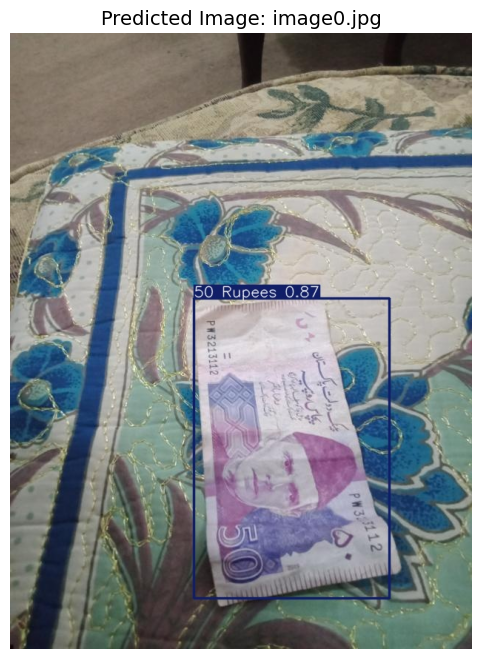

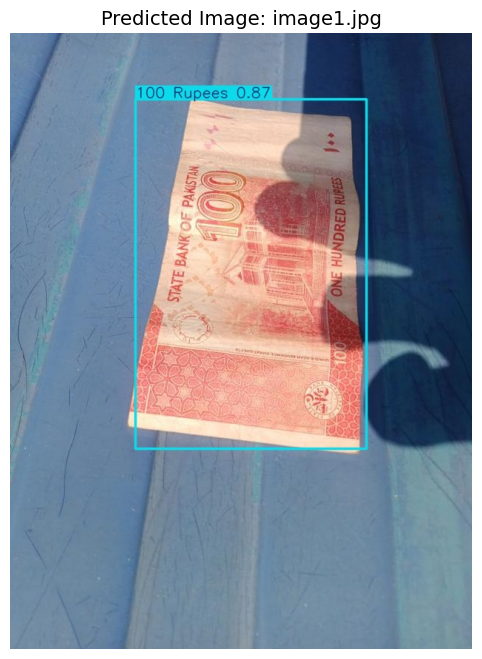

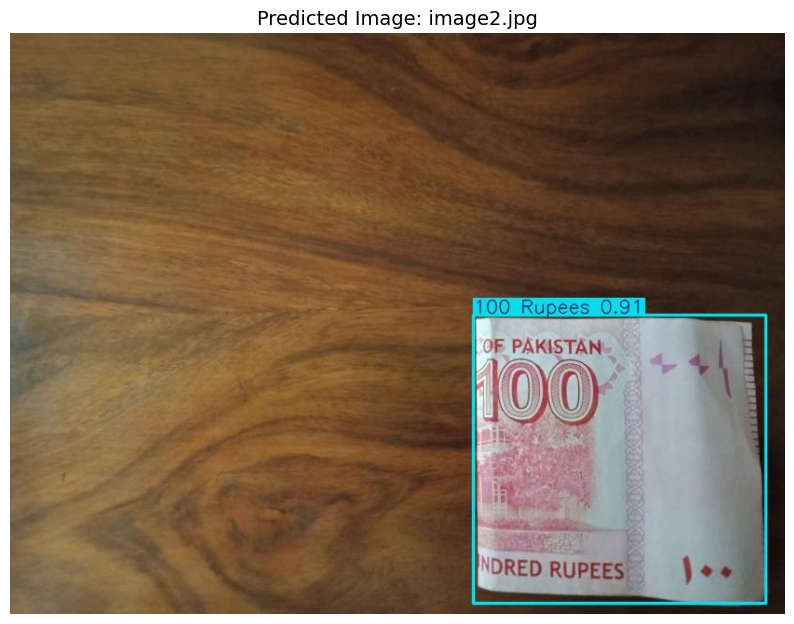

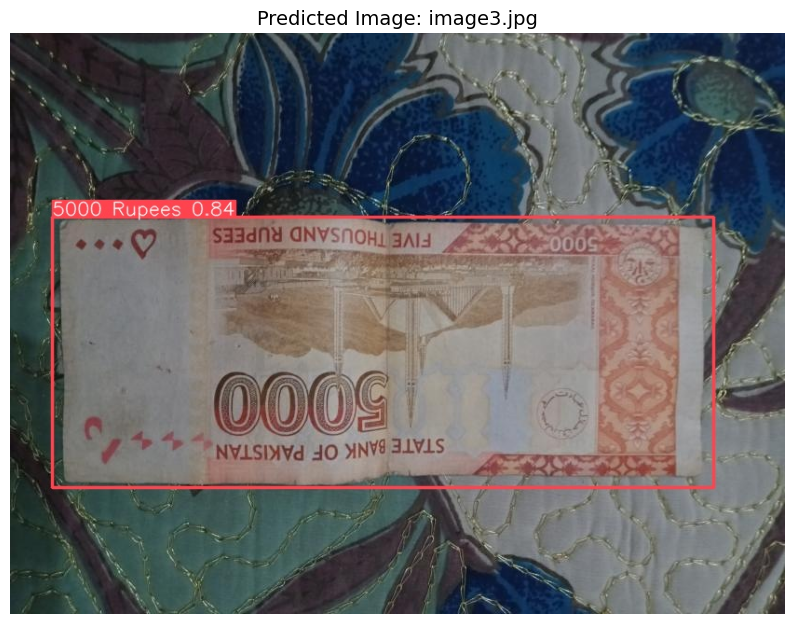

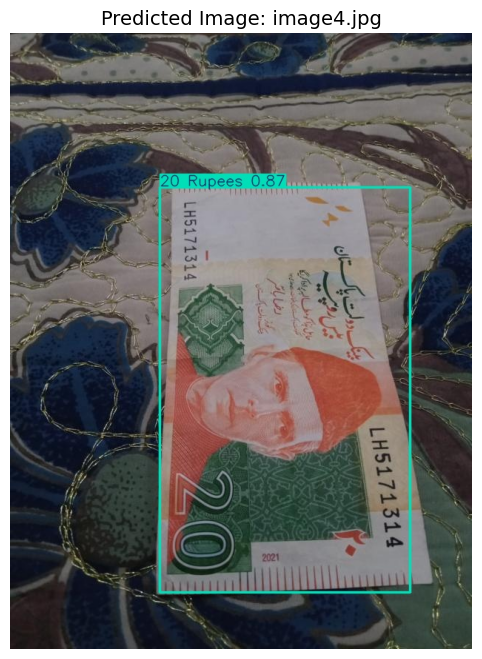

In [16]:
import matplotlib.pyplot as plt
import cv2
import os

# Get the directory where predicted images are saved
# This path is usually '/content/runs/detect/predict'
# We can get it from the 'results' object if it's still in memory
if 'results' in locals() and results and hasattr(results[0], 'save_dir'):
    prediction_save_dir = results[0].save_dir
else:
    print("Could not automatically determine prediction save directory. Assuming '/content/runs/detect/predict'.")
    prediction_save_dir = '/content/runs/detect/predict'

print(f"Loading predicted images from: {prediction_save_dir}")

# List all image files in the prediction directory
predicted_image_files = []
if os.path.exists(prediction_save_dir):
    for f in os.listdir(prediction_save_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            predicted_image_files.append(os.path.join(prediction_save_dir, f))
    predicted_image_files.sort() # Sort for consistent order
else:
    print(f"⚠️ Prediction directory not found: {prediction_save_dir}")

if predicted_image_files:
    print(f"Found {len(predicted_image_files)} predicted images. Displaying the first 5:")
    # Display a few of the predicted images
    num_images_to_show = min(len(predicted_image_files), 5) # Show up to 5 images

    for i in range(num_images_to_show):
        img_path = predicted_image_files[i]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Predicted Image: {os.path.basename(img_path)}", fontsize=14)
        plt.axis('off')
        plt.show()
else:
    print("No predicted images found in the directory.")

In [17]:
from google.colab import files

# Path where YOLO saves best model
model_path = "runs/detect/currency_detection_model_v2/weights/best.pt"

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>